# StarDist Prediction Test Notebook

Test a trained StarDist model on all images in the nuclei dataset.

**Prerequisites:** Run `test_stardist_training.ipynb` first to train the model.

**Workflow:**
1. Load project and trained model
2. Run `segment_all_files()` to segment all image files
3. Load predictions from disk
4. Visualize results

## 1. Import Libraries

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import find_boundaries

from napari_ai_lab.models.image_data_model import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.StardistSegmenter import (
    StardistSegmenter,
)

## 2. Load Project and Trained Model

In [5]:
# Load project
project_path = Path("../tests/test_images/nuclei").resolve()
model = ImageDataModel(str(project_path))

# Load trained StarDist model
model_name = "stardist_nuclei_test"
segmenter = StardistSegmenter()
segmenter.model_save_dir = str(project_path / "models")
segmenter.set_model(model_name)

print(f"Project: {project_path}")
print(f"Loaded model: {model_name}")
print(f"Found {len(model.get_image_paths())} images to segment")

🔄 Model preset changed to 'stardist_nuclei_test' - recommended axis: YX
Loading network weights from 'weights_best.h5'.
Couldn't load thresholds from 'thresholds.json', using default values. (Call 'optimize_thresholds' to change that.)
Using default values: prob_thresh=0.5, nms_thresh=0.4.
Loaded user-trained model: stardist_nuclei_test from C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\models
   Loaded downsize_factor=1 from custom_params.json
Project: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei
Loaded model: stardist_nuclei_test
Found 200 images to segment


## 3. Segment All Images

Use `segment_all_files()` to process all image files in the directory.

In [ ]:
# Progress callback
def on_progress(current, total):
    print(f"Progress: {current}/{total}")

def on_image_done(idx, mask):
    n_obj = len(np.unique(mask)) - 1
    print(f"  ✓ Image {idx + 1}: {n_obj} objects detected")

# Segment all images (saves predictions to disk automatically)
print("Starting batch prediction...")
results = model.segment_all_files(
    segmenter=segmenter,
    save_predictions=True,
    on_image_done=on_image_done,
    on_progress=on_progress,
)

print(f"\n✅ Segmented {len(results)} images and saved predictions to disk.")

Starting batch prediction...
Progress: 1/200
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB.tif
Loaded image shape: (520, 696)
Axis types: YX
Scale (per axis): [1.0, 1.0]
Using model: stardist_nuclei_test (axis: YX)
   Downsized image: (520, 696) → (260, 348) (factor=2)
🔍 StarDist input: shape=(260, 348), dtype=float32, ndim=2
🔍 TensorFlow GPU Check:
   TensorFlow version: 2.10.1
   GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Built with CUDA: True
   ✅ GPU ENABLED - using GPU acceleration
🔍 Calling model.predict_instances with shape=(260, 348), axes=None (will use model default)
   Upsized labels back to original: (260, 348) → (520, 696)
StarDist: Found 88 objects (prob_thresh=0.5, nms_thresh=0.4)
  ✓ Image 1: 88 objects detected
Progress: 2/200
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\IXMtest_A06_s6_w

## 4. Load Predictions from Disk

Load the saved predictions to verify they were written correctly.

In [7]:
# Load predictions back from disk for a few images
# Let's look at images 10-15 (indices 9-14)
image_indices = list(range(9, min(15, len(model.get_image_paths()))))

loaded_predictions = {}
loaded_images = {}

for idx in image_indices:
    # Load original image
    img = model.load_image(idx)
    loaded_images[idx] = img

    # Load prediction from disk
    pred = model.load_existing_predictions(idx)
    loaded_predictions[idx] = pred

    n_obj = len(np.unique(pred)) - 1
    print(f"Image {idx + 1}: {img.shape}, prediction: {pred.shape}, {n_obj} objects")

print(f"\n✅ Loaded {len(loaded_predictions)} predictions from disk")

Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\IXMtest_A21_s1_w1D8BF2790-C628-4109-94AF-DF6D8A3480B6.tif
Loaded image shape: (520, 696)
Axis types: YX
Scale (per axis): [1.0, 1.0]
Image 10: (520, 696), prediction: (520, 696), 60 objects
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\IXMtest_A22_s8_w1E2AFE190-831D-4D9C-961E-3AA2ECB3599D.tif
Loaded image shape: (520, 696)
Axis types: YX
Scale (per axis): [1.0, 1.0]
Image 11: (520, 696), prediction: (520, 696), 61 objects
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\IXMtest_A24_s9_w152CD6793-DA45-4975-869A-CBD49D645E37.tif
Loaded image shape: (520, 696)
Axis types: YX
Scale (per axis): [1.0, 1.0]
Image 12: (520, 696), prediction: (520, 696), 40 objects
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\napari-ai-lab\tests\test_images\nuclei\IXMtest_B02_s9_w124B5080D-EBE1-47D2-B147-C0F342039EDF.tif
Loaded image

## 5. Visualize Results

Display loaded images and predictions side-by-side.

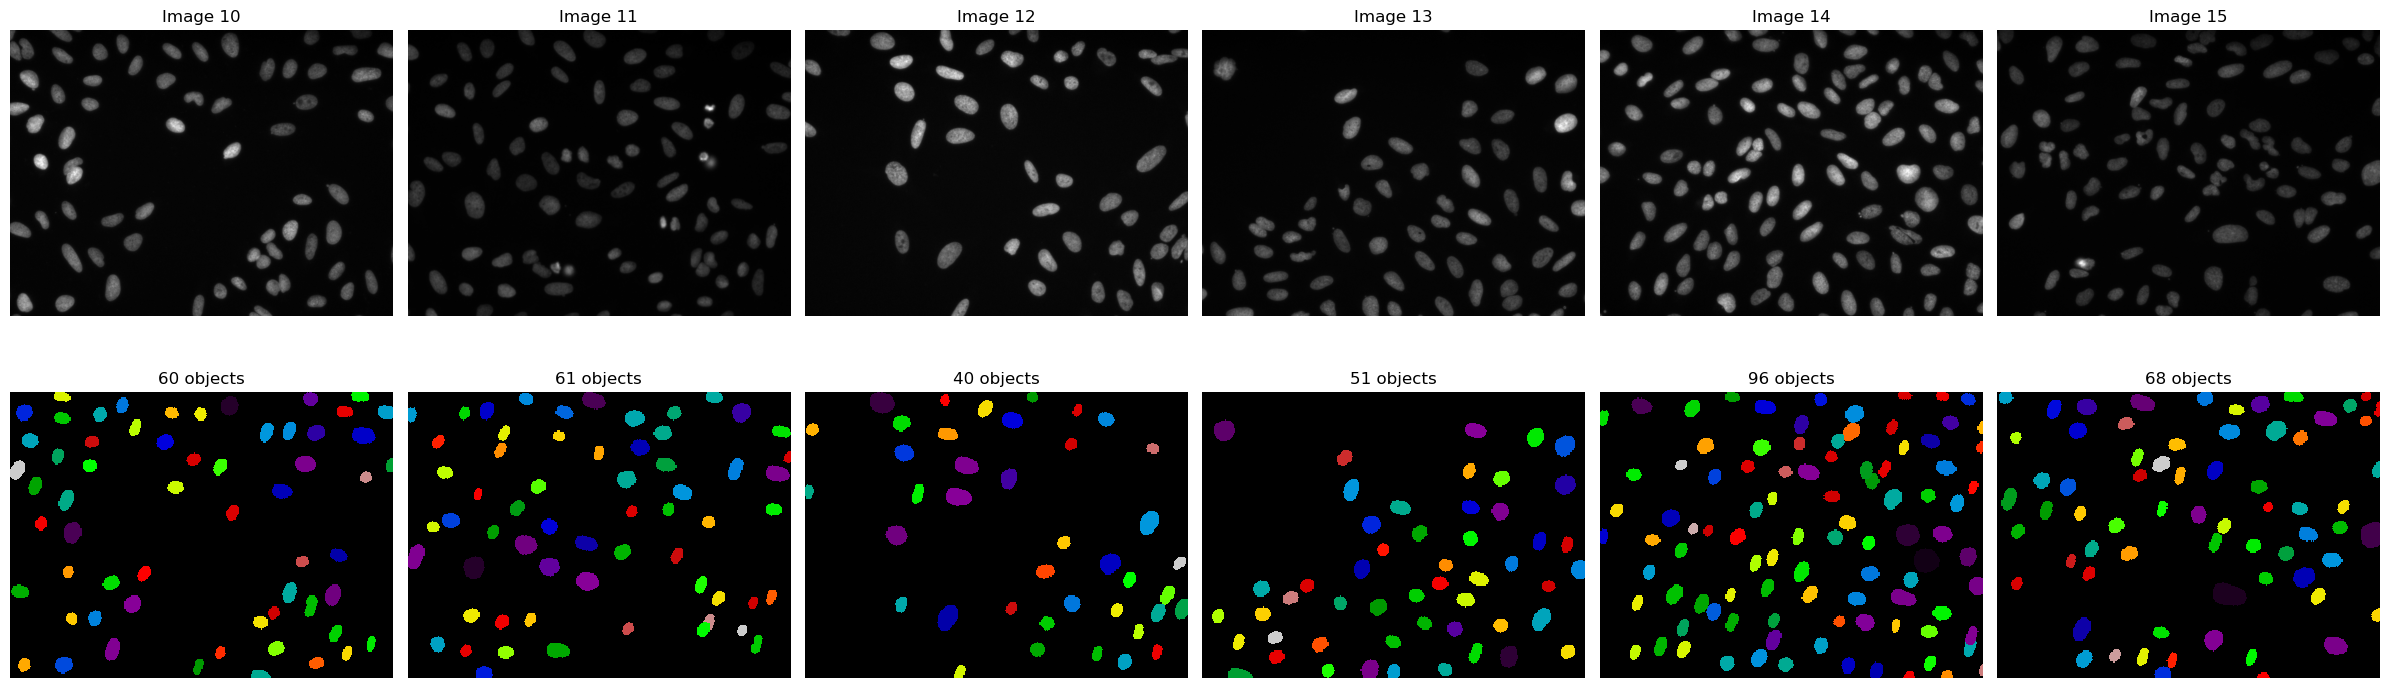

In [ ]:
# Display input images and predictions
n = len(loaded_predictions)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
if n == 1:
    axes = axes.reshape(2, 1)

for row, idx in enumerate(sorted(loaded_predictions.keys())):
    img = loaded_images[idx]
    pred = loaded_predictions[idx]
    n_obj = len(np.unique(pred)) - 1

    axes[0, row].imshow(img, cmap="gray")
    axes[0, row].set_title(f"Image {idx + 1}")
    axes[0, row].axis("off")

    axes[1, row].imshow(pred, cmap="nipy_spectral", interpolation="nearest")
    axes[1, row].set_title(f"{n_obj} objects")
    axes[1, row].axis("off")

plt.tight_layout()
plt.show()

## 6. Show Contour Overlays

Display predictions as contours overlaid on the input images.

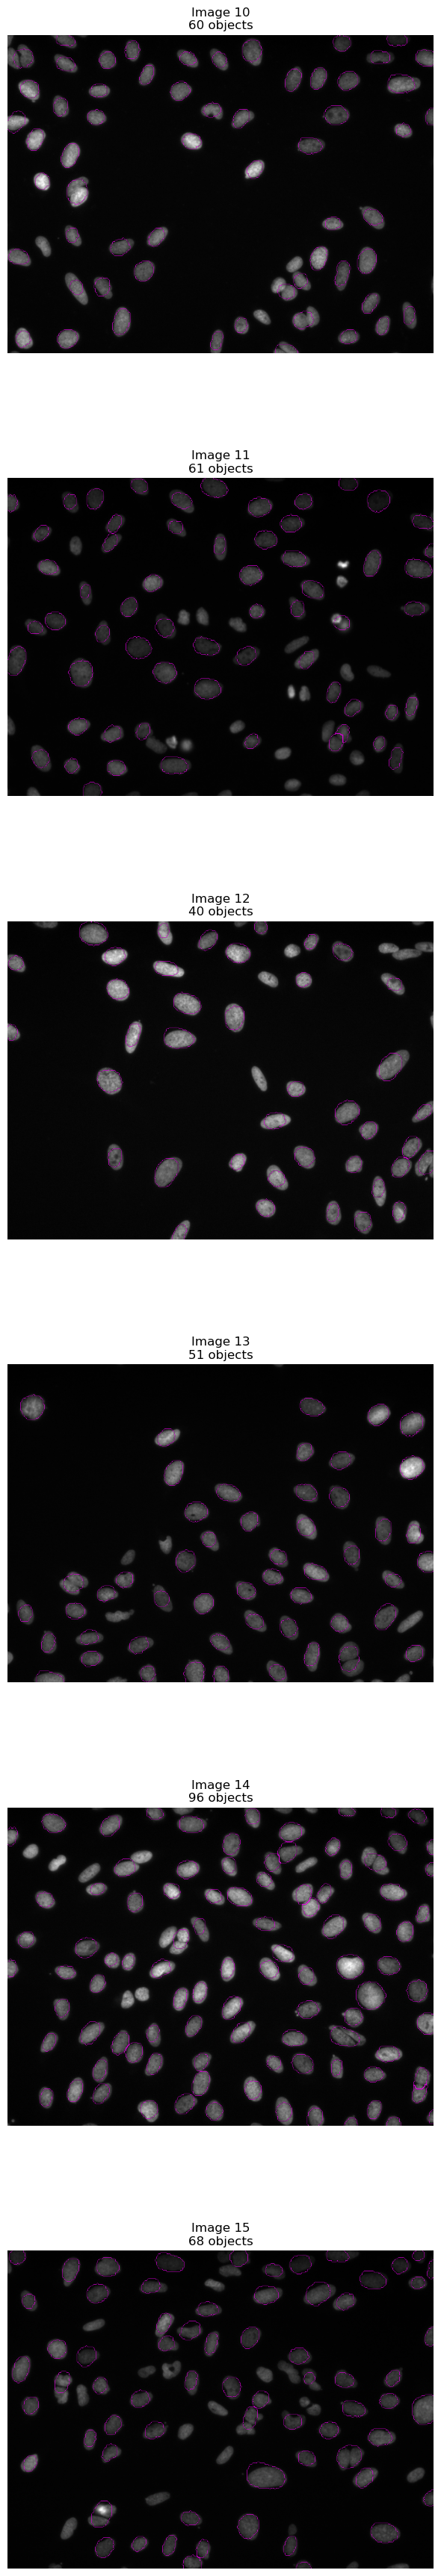

In [11]:
# Display overlays
n = len(loaded_predictions)
fig, axes = plt.subplots(n, 1, figsize=(6, 6*n))
if n == 1:
    axes = [axes]

for row, idx in enumerate(sorted(loaded_predictions.keys())):
    img = loaded_images[idx]
    pred = loaded_predictions[idx]
    bounds = find_boundaries(pred, mode="outer")
    n_obj = len(np.unique(pred)) - 1

    axes[row].imshow(img, cmap="gray")
    axes[row].imshow(np.ma.masked_where(~bounds, bounds), cmap="spring", alpha=0.8)
    axes[row].set_title(f"Image {idx + 1}\n{n_obj} objects")
    axes[row].axis("off")

plt.tight_layout()
plt.show()